In [35]:
# ===============================================================
# 1. Setup
# ===============================================================
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

plt.style.use("seaborn-v0_8")
# ===============================================================
# 2. Get S&P 500 stock data
# ===============================================================

# Static S&P 500 ticker list (can scrape dynamically, but for stability we hardcode a subset)
tickers = ["AAPL", "MSFT", "AMZN", "META", "GOOGL", "NVDA", "JPM", "JNJ", "XOM", "PG", "UNH", "TSLA"]

start = "2020-01-01"
end   = "2024-01-01"

#data = yf.download(tickers, start=start, end=end)["Adj Close"]
#data = yf.download(["AAPL","MSFT","GOOGL"], start="2020-01-01", end="2023-01-01", auto_adjust=False, progress=False)

data = yf.download(tickers, start=start, end=end, auto_adjust=False, progress=False)["Adj Close"]


data.head()

# ===============================================================
# 3. Compute daily returns
# ===============================================================
returns = data.pct_change().dropna()
print(returns.head())
# ===============================================================
# 4. Construct factor signals
# ===============================================================
# For demo purposes:
# Size   = log of market cap proxy (use last price * shares outstanding ideally)
# Value  = 1 / P/E ratio (placeholder using random fundamentals)
# Momentum = past 12m return minus last 1m return

# Download market cap and PE from yfinance (where available)
info_dict = {}
for t in tickers:
    try:
        info_dict[t] = yf.Ticker(t).info
    except:
        info_dict[t] = {}

fundamentals = pd.DataFrame(info_dict).T[["marketCap", "trailingPE"]]
print("funda",fundamentals)
# Convert to numeric, coerce errors to NaN
fundamentals["marketCap"] = pd.to_numeric(fundamentals["marketCap"], errors="coerce")

# Apply log safely
fundamentals["Size"] = np.log(fundamentals["marketCap"].astype(float))

#fundamentals["Size"] = np.log(fundamentals["marketCap"])
fundamentals["Value"] = 1 / fundamentals["trailingPE"]

# Momentum factor: compute trailing 12m – 1m returns at each rebalance date


price_monthly = data.resample("ME").last()

# Momentum = 12m return – 1m return
mom_12m = price_monthly.pct_change(12)
mom_1m  = price_monthly.pct_change(1)

# Align and take last valid row (not just .iloc[-1])
momentum = (mom_12m - mom_1m).iloc[-2]   # use -2 to ensure 12m data exists
fundamentals["Momentum"] = momentum

#momentum = (price_monthly.pct_change(12) - price_monthly.pct_change(1)).iloc[-1]
#fundamentals["Momentum"] = momentum
print(fundamentals)


Ticker          AAPL      AMZN     GOOGL       JNJ       JPM      META  \
Date                                                                     
2020-01-03 -0.009722 -0.012139 -0.005232 -0.011577 -0.013197 -0.005291   
2020-01-06  0.007968  0.014886  0.026654 -0.001248 -0.000795  0.018834   
2020-01-07 -0.004703  0.002092 -0.001932  0.006107 -0.017001  0.002163   
2020-01-08  0.016086 -0.007809  0.007118 -0.000138  0.007801  0.010138   
2020-01-09  0.021241  0.004799  0.010498  0.002966  0.003651  0.014311   

Ticker          MSFT      NVDA        PG      TSLA       UNH       XOM  
Date                                                                    
2020-01-03 -0.012451 -0.016006 -0.006725  0.029633 -0.010120 -0.008039  
2020-01-06  0.002584  0.004194  0.001387  0.019255  0.006942  0.007678  
2020-01-07 -0.009117  0.012107 -0.006191  0.038801 -0.006037 -0.008184  
2020-01-08  0.015928  0.001876  0.004263  0.049205  0.021084 -0.015080  
2020-01-09  0.012493  0.010983  0.010938 -0

In [39]:
# ===============================================================
# 5. Factor portfolio construction
# ===============================================================
def construct_factor_portfolio(signal, ret_df, quantile=0.3):
    """
    Build long-short portfolio:
    - Long top quantile
    - Short bottom quantile
    """
    n = int(len(signal) * quantile)
    top = signal.nlargest(n).index
    bottom = signal.nsmallest(n).index
    
    # Equal-weight portfolio
    long_rets = ret_df[top].mean(axis=1)
    short_rets = ret_df[bottom].mean(axis=1)
    factor_rets = long_rets - short_rets
    
    return factor_rets, top, bottom

factors = {}
for col in ["Size", "Value", "Momentum"]:
    fundamentals[col] = pd.to_numeric(fundamentals[col], errors="coerce")
for fac in ["Size", "Value", "Momentum"]:
    factor_rets, top, bottom = construct_factor_portfolio(fundamentals[fac], returns)
    factors[fac] = factor_rets

factors = pd.DataFrame(factors)
print(factors)#.head())


                Size     Value  Momentum
Date                                    
2020-01-03 -0.003252 -0.011754 -0.001233
2020-01-06  0.002555 -0.005864  0.008180
2020-01-07  0.001469 -0.025809  0.008159
2020-01-08  0.002894 -0.017787 -0.000554
2020-01-09  0.012163 -0.001550  0.008383
...              ...       ...       ...
2023-12-22 -0.005977  0.006171 -0.004858
2023-12-26 -0.000604 -0.004946  0.002371
2023-12-27 -0.001910 -0.005178  0.002949
2023-12-28  0.001446  0.007378  0.004236
2023-12-29 -0.004323  0.007903 -0.007824

[1005 rows x 3 columns]


In [40]:
# ===============================================================
# 6. Performance metrics
# ===============================================================
def performance_summary(rets, name="Portfolio"):
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    cum_ret = (1 + rets).prod() - 1
    return pd.Series(
        {"Ann.Return": ann_ret, "Ann.Vol": ann_vol, "Sharpe": sharpe, "Cumulative": cum_ret},
        name=name,
    )

perf = pd.concat([performance_summary(factors[c], c) for c in factors.columns], axis=1).T
perf


,Ann.Return,Ann.Vol,Sharpe,Cumulative
Size,0.294772,0.30888,0.954327,1.678923
Value,-0.398797,0.40679,-0.980351,-0.853781
Momentum,0.208533,0.38015,0.548554,0.721928


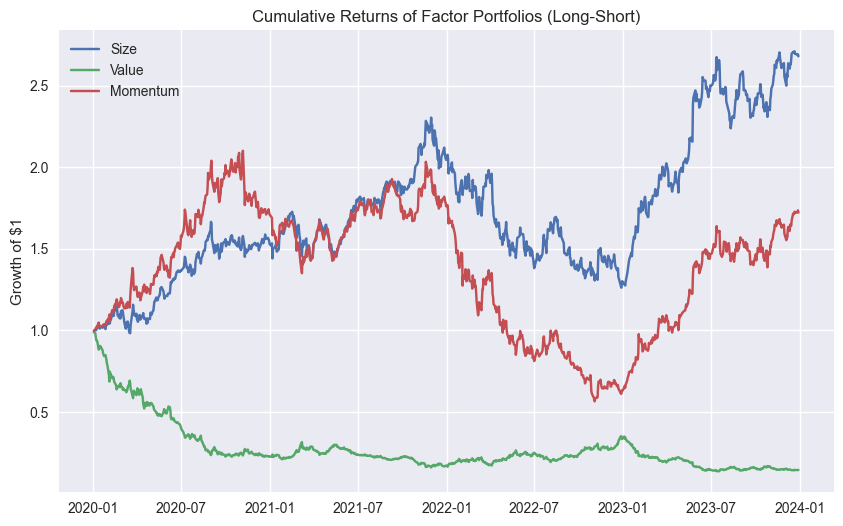

In [43]:
# ===============================================================
# 7. Visualization
# ===============================================================
cumulative = (1 + factors).cumprod()

plt.figure(figsize=(10,6))
for c in cumulative.columns:
    plt.plot(cumulative.index, cumulative[c], label=c)
plt.legend()
plt.title("Cumulative Returns of Factor Portfolios (Long-Short)")
plt.ylabel("Growth of $1")
plt.show()

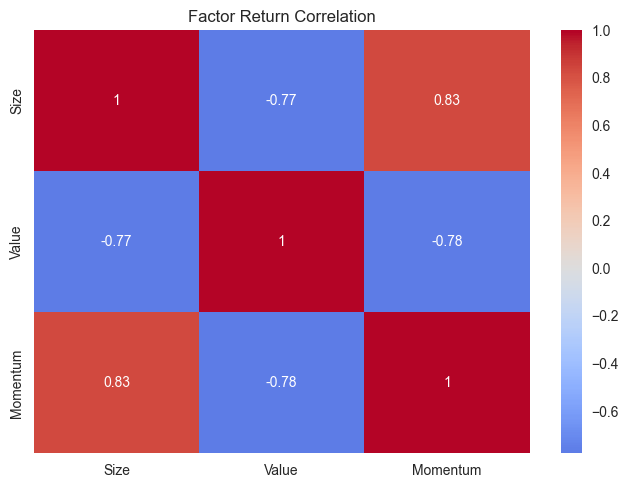

In [29]:
# ===============================================================
# 8. Factor correlation & risk diversification
# ===============================================================
sns.heatmap(factors.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Factor Return Correlation")
plt.show()